In [13]:
#load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
df = pd.read_csv("bd_labs_after.csv")

#drop patients missing sex or age
#code sex as numeric: 0 for female, 1 for male
df = df.dropna(subset=["Age", "Sex"])
df["Sex"] = df["Sex"].map({"Female": 0, "Male": 1})

#define lab columns
lab_cols = [
    "TOTAL CHOLESTEROL", "HBA1C", "HDL", 
    "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"
]

# Calculate % missing for each lab marker
missing_percent = df[lab_cols].isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

# Print nicely
print("Missing data percentage per lab marker:")
print(missing_percent)

Missing data percentage per lab marker:
GLUCOSE TOLERANCE    99.916318
INR                  68.619247
HBA1C                68.535565
LDL                  55.983264
HDL                  54.644351
TOTAL CHOLESTEROL    52.133891
FASTING GLUCOSE      50.125523
dtype: float64


In [14]:
#drop unwanted lab markers with too much missingness
df = df.drop(columns=["HBA1C", "INR", "GLUCOSE TOLERANCE"])
lab_cols = ["TOTAL CHOLESTEROL", "HDL", "FASTING GLUCOSE", "LDL"]
auxiliary_cols = ["Age", "Sex"]

In [15]:
from sklearn.impute import KNNImputer
knn_cols = auxiliary_cols + lab_cols
df_original = df.copy()

imputer = KNNImputer(n_neighbors=5)

In [16]:
#imputation without scaling age and sex
df_unscaled = df.copy()

df_unscaled[knn_cols] = imputer.fit_transform(df_unscaled[knn_cols])

df_unscaled.to_csv("bd_labs_after_knn_cleaned.csv", index=False)


In [17]:
#imputation with scaled age and sex
df_scaled = df.copy()
df_scaled["Age"] = df_scaled["Age"] * 2
df_scaled["Sex"] = df_scaled["Sex"] * 2


df_scaled[knn_cols] = imputer.fit_transform(df_scaled[knn_cols])

df_scaled.to_csv("bd_labs_after_knn_scaled.csv", index=False)

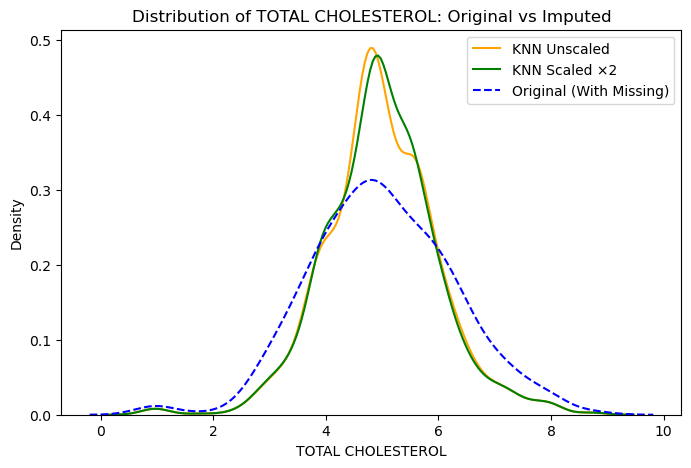

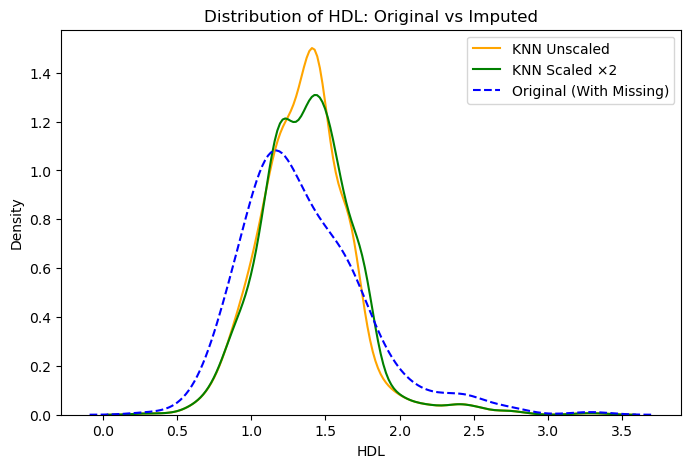

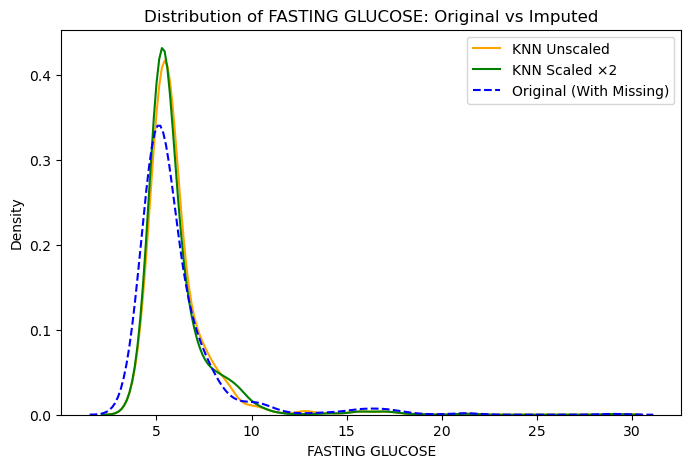

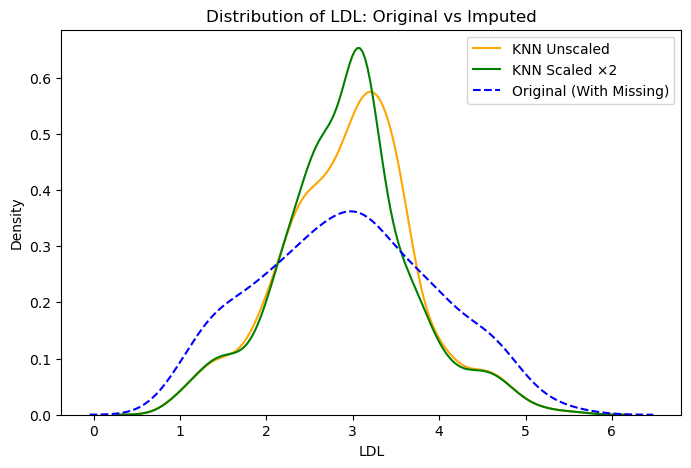

In [18]:
for col in lab_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(df_unscaled[col], label="KNN Unscaled", color="orange")
    sns.kdeplot(df_scaled[col], label="KNN Scaled ×2", color="green")
    sns.kdeplot(df_original[col], label="Original (With Missing)", color="blue", linestyle="--")
    plt.title(f"Distribution of {col}: Original vs Imputed")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()
